Dea Kayla P. D. / 3323600005 / 3 Sains Data Terapan A

# Import Library

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Load Data

In [15]:
df = pd.read_csv('tiktok_bersih.csv')
df

,waktu_interaksi,text_final,diggCount,replyCommentTotal
0,2025-08-29 10:57:40+00:00,habis urus berkas sampe kesana please,40,4.0
1,2025-09-02 15:27:02+00:00,template essaynya,0,0.0
2,2025-08-29 23:41:26+00:00,essay,0,0.0
3,2025-09-02 16:15:40+00:00,anak gapyear cantumin nilai rapot lanjur gapyear,0,0.0
4,2025-08-31 10:51:50+00:00,nilai,10,0.0
...,...,...,...,...
220,2025-01-29 10:50:40+00:00,video langsung bayang kedip,1,0.0
221,2025-05-15 11:47:18+00:00,percaya biaya hidup,3,0.0
222,2025-06-04 09:23:42+00:00,tes ielts toefl,0,0.0
223,2025-05-11 07:48:10+00:00,ielts,0,0.0


# Check Missing Value

Memeriksa apakah terdapat data yang hilang (NaN) dalam dataset menggunakan df.info().
Outputnya menunjukkan bahwa kolom text_final memiliki nilai yang hilang sebanyak 20
baris (205 non-null dari 225 total baris). Hal ini kemungkinan terjadi karena text aslinya
dilakukan stopword sehingga komentar pendek terhapus sehingga hasilnya kosong. Bisa
juga karena text aslinya hanya berisi emoticon ataupun whitespace sehingga saat dilakukan
proses cleaning, text nya menjadi string kosong

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 225 entries, 0 to 224
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   waktu_interaksi    225 non-null    object 
 1   text_final         205 non-null    object 
 2   diggCount          225 non-null    int64  
 3   replyCommentTotal  225 non-null    float64
dtypes: float64(1), int64(1), object(2)
memory usage: 7.2+ KB


# Drop Missing Values

Untuk menangani data yang hilang dalam dataset, saya gunakan fungsi dropna untuk
mengahpus nilai NaN karena NaN pada kolom tersebut tidak memiliki makna apapun untuk
dilakukan analisis lebih lanjut. Output dari df.info() kedua menunjukkan bahwa nilai NaN
pada kolom text_final sudah terhapus

In [17]:
df.dropna(subset=['text_final'], inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 205 entries, 0 to 224
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   waktu_interaksi    205 non-null    object 
 1   text_final         205 non-null    object 
 2   diggCount          205 non-null    int64  
 3   replyCommentTotal  205 non-null    float64
dtypes: float64(1), int64(1), object(2)
memory usage: 8.0+ KB


# Rename Column

Melakukan rename pada kedua kolom terakhir yaitu diggCount dan replyCommentTotal
agar lebih mudah dipahami. Kolom diggCount diubah menjadi jumlah_like, yang
merepresentasikan jumlah tanda suka (likes) pada setiap interaksi. Kolom
replyCommentTotal diubah menjadi jumlah_balasan, yang merepresentasikan total
komentar balasan terhadap interaksi utama.

In [18]:
df.rename(columns={'diggCount': 'jumlah_like', 'replyCommentTotal': 'jumlah_balasan'}, inplace=True)
df

,waktu_interaksi,text_final,jumlah_like,jumlah_balasan
0,2025-08-29 10:57:40+00:00,habis urus berkas sampe kesana please,40,4.0
1,2025-09-02 15:27:02+00:00,template essaynya,0,0.0
2,2025-08-29 23:41:26+00:00,essay,0,0.0
3,2025-09-02 16:15:40+00:00,anak gapyear cantumin nilai rapot lanjur gapyear,0,0.0
4,2025-08-31 10:51:50+00:00,nilai,10,0.0
...,...,...,...,...
220,2025-01-29 10:50:40+00:00,video langsung bayang kedip,1,0.0
221,2025-05-15 11:47:18+00:00,percaya biaya hidup,3,0.0
222,2025-06-04 09:23:42+00:00,tes ielts toefl,0,0.0
223,2025-05-11 07:48:10+00:00,ielts,0,0.0


# Descriptive statistics

Untuk melihat statistik deskripsi pada kolom numerik, maka digunakan fungsi describe().

In [19]:
df.describe()

,jumlah_like,jumlah_balasan
count,205.000000,205.000000
mean,88.448780,0.917073
std,701.017827,3.677962
min,0.000000,0.000000
25%,0.000000,0.000000
50%,1.000000,0.000000
75%,3.000000,0.000000
max,8158.000000,38.000000


Dapat dilihat dari outputnya bahwa kolom numerik hanya ada 2 yaitu kolom jumlah_like
dan jumlah_balasan.
- Untuk count kedua kolom terdapat 205 baris
- Mean pada kolom jumlah_like sebesar 88.45 yang artinya rata-rata komentar memperoleh sekitar 88 like. Sedangkan, untuk kolom jumlah_balasan memiliki mean sebesar 0.92 yang mengartikan rata-rata komentar hanya mendapat kurang dari 1 balasan
- Standar deviasi pada kolom jumlah_like sebesar 701.02 yang artinya distribusi data yang sangat menyebar, maka terdapat komentar dengan jumlah like yang sangat tinggi dibandingkan mayoritas komentar. Untuk kolom jumlah_balasan sebesar 3.68, dimana nilainya lebih kecil dibandingkan jumlah_like
- Nilai min=0 dan max=8158 pada kolom jumlah_like yang mengartikan terdapat komentar tanpa like sama sekali, dan terdapat komentar dengan like terbanyak sebesar 8158. Untuk kolom jumlah_balasan, nilai min=0 dan max=38 yang artinya sebagian komentar tidak memiliki balasan (reply) dan ada juga komentar dengan reply terbanyak sebanyak 38 reply
- Nilai median untuk kolom jumlah_like sebanyak 1 yang artinya setengah dari komentar hanya mendapat 1 like atau kurang, sedangkan pada kolom jumlah_balasan nilai mediannya 0 yang artinya  lebih dari setengah komentar tidak mendapatkan reply sama sekali
- Untuk nilai kuartil pada kolom jumlah_like sebanyak 3 yang artinya 75% komentar memperoleh 3 like atau kurang, sedangkan pada kolom jumlah__balasan nilai kuartilnya 0 yang artinya 75% komentar sama sekali tidak memiliki reply

# DateTime

Pada kolom createTimeISO berisi informasi waktu dalam bentuk teks. Maka, diubah ke
datetime terlebih dahulu dikarenakan analisis yang akan dilakukan adalah User Behavior
Analysis. Menggunakan fungsi pd.to_datetime() untuk mengonversi. Setelah itu,
jam_interaksi dan hari_interaksi diekstrak dari kolom datetime yang baru

In [20]:
df['waktu_interaksi'] = pd.to_datetime(df['waktu_interaksi'])
df['jam_interaksi'] = df['waktu_interaksi'].dt.hour
df['hari_interaksi'] = df['waktu_interaksi'].dt.day_name()
df[['waktu_interaksi', 'jam_interaksi', 'hari_interaksi']]

,waktu_interaksi,jam_interaksi,hari_interaksi
0,2025-08-29 10:57:40+00:00,10,Friday
1,2025-09-02 15:27:02+00:00,15,Tuesday
2,2025-08-29 23:41:26+00:00,23,Friday
3,2025-09-02 16:15:40+00:00,16,Tuesday
4,2025-08-31 10:51:50+00:00,10,Sunday
...,...,...,...
220,2025-01-29 10:50:40+00:00,10,Wednesday
221,2025-05-15 11:47:18+00:00,11,Thursday
222,2025-06-04 09:23:42+00:00,9,Wednesday
223,2025-05-11 07:48:10+00:00,7,Sunday


Tiga kolom berhasil dibuat yaitu waktu_interaksi, jam_interaksi, dan hari_interaksi. Data ini
akan digunakan untuk menganalisis pola aktivitas pengguna berdasarkan jam dan harinya.
Contohnya pada baris nomor 0, waktu interaksinya pada tanggal 29 Agustus 2025 pukul
10.57 waktu UTC yang jika diekstrak menghasilkan jam interaksi ke-10 yaitu jam 17.57
WIB dan hari interaksinya pada hari jum’at.

# Analysis of Interaction Time Patterns

## A. Most Active Hours

Memvisualisasikan pola waktu dari komentar video berdasarkan jamnya

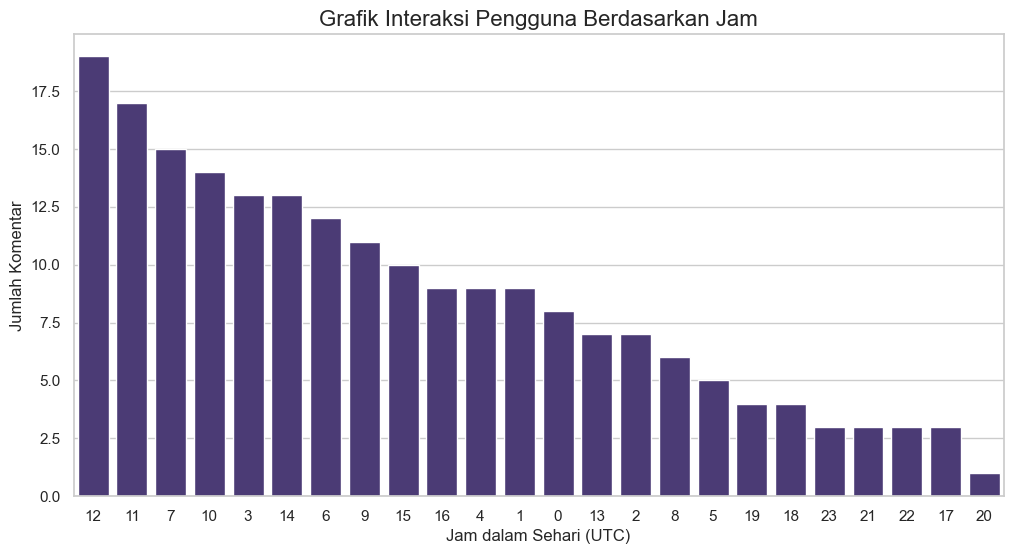

In [21]:
sns.set_theme(style="whitegrid", palette="viridis")
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='jam_interaksi', order = df['jam_interaksi'].value_counts().index)
plt.title('Grafik Interaksi Pengguna Berdasarkan Jam', fontsize=16)
plt.xlabel('Jam dalam Sehari (UTC)', fontsize=12)
plt.ylabel('Jumlah Komentar', fontsize=12)
plt.show()

Dapat dilihat pada bar chart dibawah ini, jam dengan frekuensi tertinggi adalah jam 12
UTC atau pukul 19.00 WIB dengan hampir 19 komentar. Pada jam-jam dini hari
misalnya jam 20 UTC atau 03.00 WIB, interaksinya sangat rendah. Hanya sekitar 1
komentar. Sehingga dapat disimpulkan, puncak aktivitas user terjadi pada sore hingga
malam hari waktu Indonesia, sedangkan aktivitas paling rendah terjadi pada dini hari.

## B. Most Active Day

Memvisualisasikan total komentar yang masuk pada masing-masing hari

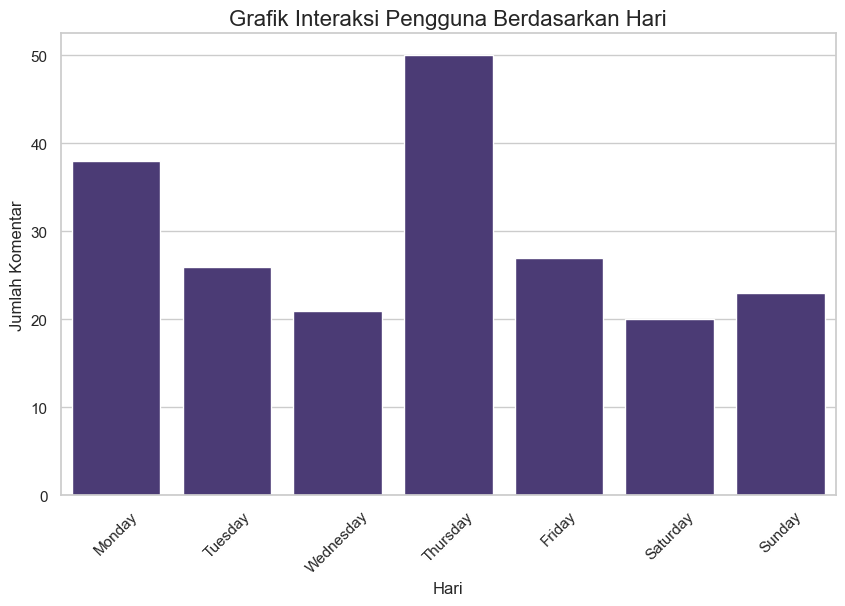

In [22]:
hari_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='hari_interaksi', order=hari_order)
plt.title('Grafik Interaksi Pengguna Berdasarkan Hari', fontsize=16)
plt.xlabel('Hari', fontsize=12)
plt.ylabel('Jumlah Komentar', fontsize=12)
plt.xticks(rotation=45)
plt.show()

Dapat dilihat pada bar chart dibawah ini, puncak interaksi terjadi pada hari Kamis
dengan jumlah komentar sekitar 50 komentar yang jauh lebih tinggi dibandingkan hari
lainnya. Hari senin juga cukup tinggi sekitar 38 komentar yang menunjukkan adanya
aktivitas signifikan pada awal peka. Hari dengan interaksi terendah adalah Sabtu, hanya
sekitar 20 komentar. Dapat disimpulkan, bahwa hari kamis adalah puncak aktivitas.

# Analysis of Differences in Behavior Patterns

Untuk mengetahui pola kebiasaan user, maka klasifikasikan terlebih dahulu minat user
berdasarkan komentarnya. Disini saya membuat fungsi untuk mengidentifikasi apakah suatu
teks lebih berkaitan dengan beasiswa dan persiapan studi atau dengan kehidupan di luar
negeri. Proses klasifikasi dilakukan melalui pendekatan berbasis pencocokan kata kunci
(keyword matching) yaitu kata kunci beasiswa dan kata kunci kehidupan.
Berdasarkan keberadaan kata kunci dalam teks, sistem mengelompokkan data ke dalam 4
kategori:
- Beasiswa & Kehidupan (jika teks mengandung kedua jenis kata kunci)
- Fokus Beasiswa & Persiapan (jika teks mengandung kata kunci beasiswa)
- Fokus Kehidupan di LN (jika teks mengandung kata kunci kehidupan)
- Lainnya (jika teks tidak mengandung kata kunci dari kedua kategori)

In [23]:
def kategorikan_minat_revisi(teks):
    if not isinstance(teks, str):
        return 'Lainnya'

    kata_kunci_beasiswa = [
        'template', 'beasiswa', 'biaya', 'gratis', 'essay', 'ielts',
        'toefl', 'nilai', 'berkas', 'syarat', 'daftar', 'exchange',
        'fully funded', 'scholarship', 'apply'
    ]
    kata_kunci_kehidupan = [
        'hidup', 'tinggal', 'suasana', 'kerja', 'budaya', 'culture',
        'kota', 'jalan', 'urus', 'visa', 'australia', 'canada',
        'jepang', 'eropa', 'korea', 'singapore', 'negara'
    ]

    ada_beasiswa = any(kata in teks for kata in kata_kunci_beasiswa)
    ada_kehidupan = any(kata in teks for kata in kata_kunci_kehidupan)

    if ada_beasiswa and ada_kehidupan:
        return 'Beasiswa & Kehidupan'
    elif ada_beasiswa:
        return 'Fokus Beasiswa & Persiapan'
    elif ada_kehidupan:
        return 'Fokus Kehidupan di LN'
    else:
        return 'Lainnya'

df['kategori_minat'] = df['text_final'].apply(kategorikan_minat_revisi)

## A. Post Frequency by Interest Category

Memvisualisasikan distribusi topik komentar berdasarkan kategori minat yang
sebelumnya telah ditentukan melalui fungsi klasifikasi berbasis kata kunci

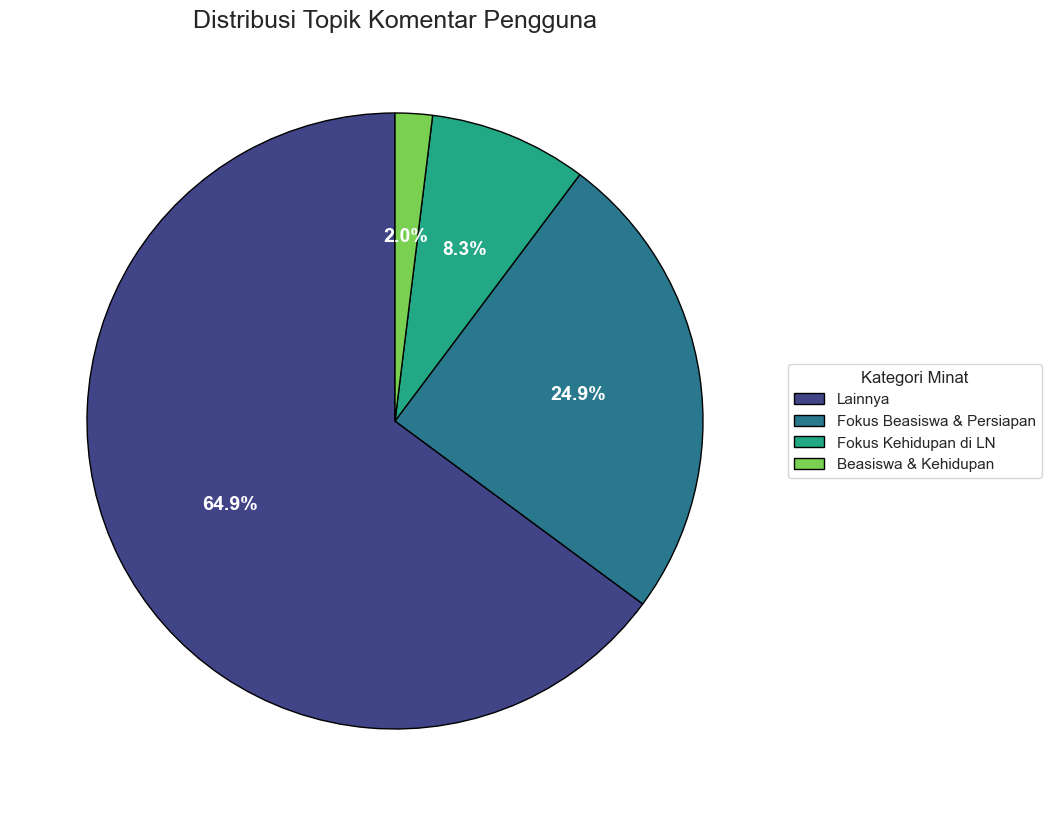

In [24]:
sns.set_theme(style="whitegrid")
custom_colors = sns.color_palette("viridis", n_colors=df['kategori_minat'].nunique())

plt.figure(figsize=(12, 10)) 
pie_chart = df['kategori_minat'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    colors=custom_colors,
    wedgeprops={'edgecolor': 'black', 'linewidth': 1},
    textprops={'fontsize': 14, 'color': 'white', 'fontweight': 'bold'}
)

plt.title('Distribusi Topik Komentar Pengguna', fontsize=18)
plt.ylabel('')

plt.legend(
    title='Kategori Minat',
    labels=df['kategori_minat'].value_counts().index,
    loc='center left',
    bbox_to_anchor=(1, 0, 0.5, 1) 
)
plt.show()

Dapat dilihat pada pie chart dibawah ini, kategori “Lainnya” mendominasi distribusi
sebesar 64.9% yang menunjukkan bahwa sebagian besar komentar user tidak
mengandung kata kunci yang terkait dengan beasiswa maupun kehidupan di luar negeri.
Contohnya kata keren, semangat, follow, done, dll. Untuk kategori Fokus Beasiswa &
Persiapan menempati posisi kedua sebesar 24.9% yang mengindikasikan adanya minat
terhadap informasi beasiswa, persyaratan, maupun persiapan studi. Kategori Fokus
Kehidupan di LN hanya 8.3% yang menandakan bahwa minat terhadap pengalaman
hidup sehari-hari di luar negeri relatif lebih rendah dibandingkan fokus akademik.
Terakhir, kategori Beasiswa & Kehidupan menjadi paling kecil dengan 2% yang
menunjukkan hanya sedikit komentar yang membahas kedua aspek secara bersamaan.
Dapat disimpulkan bahwa minat utama user lebih ke pencarian informasi beasiswa dan
persiapan studi dibandingkan aspek kehidupan di luar negeri

## B. Engagement Differences by Interest Category

Memvisualisasikan tingkat engagement user melalui rata-rata jumlah likes pada tiap
kategori minat yang sebelumnya sudah diklasifikasikan

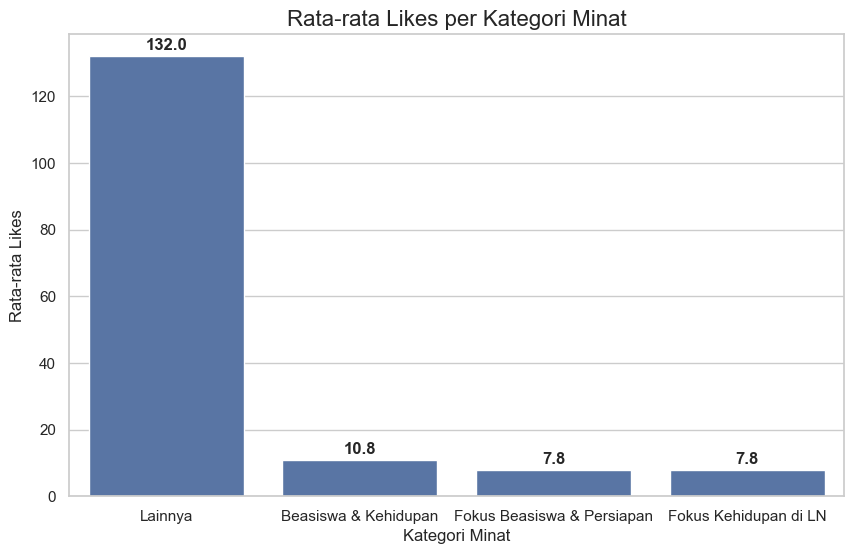

In [25]:
engagement_per_kategori = df.groupby('kategori_minat')['jumlah_like'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=engagement_per_kategori.index, y=engagement_per_kategori.values)

plt.title('Rata-rata Likes per Kategori Minat', fontsize=16)
plt.xlabel('Kategori Minat', fontsize=12)
plt.ylabel('Rata-rata Likes', fontsize=12)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center',
                xytext=(0, 8),
                textcoords='offset points',
                fontsize=12,
                fontweight='bold')

plt.show()

Dapat dilihat pada bar chart dibawah ini, kategori Lainnya memiliki rata-rata likes yang
jauh lebih tinggi sebesar 132 dibandingkan kategori lainnya. Untuk kategori Beasiswa
& Kehidupan menempati posisi kedua dengan rata-rata 10.8 like yang menunjukkan
engagement yang lebih tinggi dibandingkan kategori tunggal lainnya. Kategori Fokus
Beasiswa & Persiapan dan Fokus Kehidupan di LN sama-sama memiliki rata-rata
engagement yang rendah sekitar 7.8. Dapat disimpulkan bahwa meskipun minat user
banyak terfokus pada beasiswa dan persiapan studi, tingkat engagement tertinggi justru
muncul pada konten yang masuk kategori Lainnya.

# Word Cloud

Memvisualisasikan frekuensi kata-kata yang paling sering muncul dari keseluruhan data teks
yang telah dibersihkan agar terdapat gambaran mengenai topik utama yang dibahas dalam
komentar.

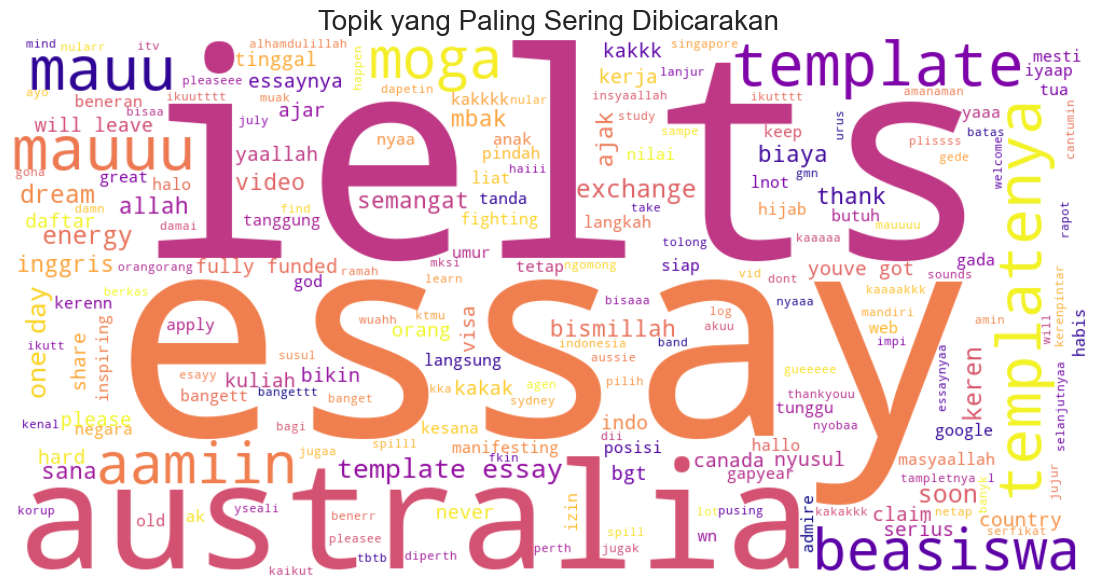

In [26]:
all_text = ' '.join(df['text_final'])
wordcloud = WordCloud(width=1000, height=500, background_color='white', colormap='plasma').generate(all_text)
plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Topik yang Paling Sering Dibicarakan', fontsize=20)
plt.show()

Dapat dilihat dari visualisasi work cloud dibawah, bahwa kata yang paling dominan adalah
essay, ielts, template, dan australia.